In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from symbolic.config import SymbolicTrainConfig
from symbolic.export import extract_dataset_from_teacher, summarize_symbolic_export
from symbolic.train import (
    train_symbolic_tree,
    evaluate_heldout,
    load_symbolic_tree,
    prune_symbolic_tree,
)
from util.artifacts import next_run_artifacts, latest_run_checkpoint
from util.config import load_yaml
from util.device import select_device

train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
symbolic_train_config = load_yaml(Path("symbolic_train.yaml"), SymbolicTrainConfig)

device = select_device(train_config["device"])
class_names = tuple(train_config["dataset"]["class_names"])

checkpoint_path = Path("checkpoints") / "neuro" / "BESTEST.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

symbolic_dir = Path("checkpoints") / "symbolic"
next_run = next_run_artifacts(symbolic_dir)
teacher_trainval_path = symbolic_dir / "teacher_trainval.pt"
teacher_test_path = symbolic_dir / "teacher_test.pt"
symbolic_checkpoint_path = next_run.checkpoint_path
symbolic_summary_path = next_run.metrics_path

checkpoint_path, class_names

(PosixPath('checkpoints/neuro/BESTEST.pt'),
 ('open', 'short', 'mouse_bite', 'spur', 'pinhole', 'spurious_copper'))

In [2]:
trainval_dataset = PCBDataset(train_config, "trainval.txt")
trainval_dataset.add_preprocess(test_preprocess())

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())

symbolic_data_config = symbolic_train_config["data"]
storage_dtype = str(symbolic_data_config["storage_dtype"])

len(trainval_dataset), len(test_dataset)

(1000, 500)

In [3]:
extract_dataset_from_teacher(
    model=model,
    dataset=trainval_dataset,
    output_path=teacher_trainval_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)
extract_dataset_from_teacher(
    model=model,
    dataset=test_dataset,
    output_path=teacher_test_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)

teacher_trainval_path, teacher_test_path

Skipping teacher dataset extraction; found existing artifact at checkpoints/symbolic/teacher_trainval.pt.
Skipping teacher dataset extraction; found existing artifact at checkpoints/symbolic/teacher_test.pt.


(PosixPath('checkpoints/symbolic/teacher_trainval.pt'),
 PosixPath('checkpoints/symbolic/teacher_test.pt'))

In [4]:
trainval_manifest, trainval_overview, trainval_counts = summarize_symbolic_export(
    teacher_trainval_path,
    "trainval",
)
test_manifest, test_overview, test_counts = summarize_symbolic_export(
    teacher_test_path,
    "test",
)

display(pd.concat([trainval_overview, test_overview], ignore_index=True))
display(pd.concat([trainval_counts, test_counts], ignore_index=True))

,split,images,total_rois,background_rois,positive_rois,feature_shape,feature_cut,symbolic_target,proposal_source
0,trainval,1000,1000000,866064,133936,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess
1,test,500,500000,437148,62852,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess


,split,class_name,count
0,trainval,__background__,866064
1,trainval,open,27020
2,trainval,short,18704
3,trainval,mouse_bite,26871
4,trainval,spur,21519
5,trainval,pinhole,19090
6,trainval,spurious_copper,20732
7,test,__background__,437148
8,test,open,13707
9,test,short,9387


## Training

In [5]:
summary, training_state = train_symbolic_tree(
    export_path=teacher_trainval_path,
    output_path=symbolic_checkpoint_path,
    summary_path=symbolic_summary_path,
    config=symbolic_train_config,
)
summary = prune_symbolic_tree(
    **training_state,
    checkpoint_path=symbolic_checkpoint_path,
    summary_path=symbolic_summary_path,
)
summary

Loading symbolic training export from checkpoints/symbolic/teacher_trainval.pt...
Symbolic training data ready in 3s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         267,872
open                      |          27,020
short                     |          18,704
mouse_bite                |          26,871
spur                      |          21,519
pinhole                   |          19,090
spurious_copper           |          20,732

Loaded 401808 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=6, lambda=25, alpha=1.
Workload check: 15 TAO iterations and up to 945 LIBLINEAR node fits.
Each TAO iteration gets its

TAO 15/15 nodes: 100%|██████████| 63/63 [02:24<00:00,  2.30s/it, iteration_done | mimic=0.9747 nz=116307]


=== Pruning Symbolic Tree ===
Tree: 401,808 RoIs, 63 internal nodes
Walking 63 internal nodes (reverse BFS)...
  Node 62 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 61 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 60 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 59 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 58 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 57 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 56 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 55 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 52 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 51 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 48 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 47 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 44 (de

{'export_path': 'checkpoints/symbolic/teacher_trainval.pt',
 'output_path': 'checkpoints/symbolic/run6.pt',
 'metrics': {'tree_depth': 6,
  'num_leaves': 64,
  'num_internal_nodes': 63,
  'nonzero_weights': 6547,
  'mean_nonzero_per_node': 103.92063492063492,
  'active_internal_nodes': 24,
  'mean_nonzero_per_active_node': 272.7916666666667},
 'history': [{'mimic_accuracy': 0.8804453868514315,
   'nonzero_weights': 150782,
   'mean_nonzero_per_node': 2393.3650793650795,
   'active_internal_nodes': 63,
   'iteration': 1},
  {'mimic_accuracy': 0.9676412614980289,
   'nonzero_weights': 118178,
   'mean_nonzero_per_node': 1875.8412698412699,
   'active_internal_nodes': 61,
   'iteration': 2},
  {'mimic_accuracy': 0.9716705491179867,
   'nonzero_weights': 118757,
   'mean_nonzero_per_node': 1885.031746031746,
   'active_internal_nodes': 60,
   'iteration': 3},
  {'mimic_accuracy': 0.9728054195038426,
   'nonzero_weights': 115839,
   'mean_nonzero_per_node': 1838.7142857142858,
   'active_in

## Heldout Evaluation

In [6]:
heldout_eval = evaluate_heldout(
    export_path=teacher_test_path,
    checkpoint_path=symbolic_checkpoint_path,
)
hm = heldout_eval["metrics"]
print(
    f"Mimic accuracy: {hm['mimic_accuracy']:.4f}\n"
    f"Macro F1: {hm.get('macro_f1_vs_teacher', 0.0):.4f}\n"
    f"Necessity flip rate: {hm.get('necessity_prediction_flip_rate', 0.0):.4f}\n"
    f"Sufficiency preservation: {hm.get('sufficiency_prediction_preservation', 0.0):.4f}\n"
    f"Deletion AUC: {hm.get('deletion_auc', 0.0):.4f}\n"
    f"Insertion AUC: {hm.get('insertion_auc', 0.0):.4f}"
)
print("Per-class agreement:")
for cls, val in hm.get("per_class_agreement_vs_teacher", {}).items():
    print(f"  {cls}: {val:.4f}")
print(
    f"Spatial — overlap: {hm.get('box_grounded_roi_overlap', 0.0):.4f}, pointing: {hm.get('pointing_score', 0.0):.4f}"
)

Loading heldout evaluation data from checkpoints/symbolic/teacher_test.pt...
Loaded 500,000 samples in 1s
Evaluating on held-out set...


Spatial grounding: 100%|██████████| 500000/500000 [01:17<00:00, 6432.17it/s]


Mimic accuracy: 0.9712
Macro F1: 0.9046
Necessity flip rate: 0.1507
Sufficiency preservation: 1.0000
Deletion AUC: 0.7718
Insertion AUC: 0.8175
Per-class agreement:
  __background__: 0.9728
  open: 0.9650
  short: 0.9256
  mouse_bite: 0.9692
  spur: 0.9734
  pinhole: 0.9653
  spurious_copper: 0.9571
Spatial — overlap: 0.6491, pointing: 0.8172


### Single SODT Student Metrics

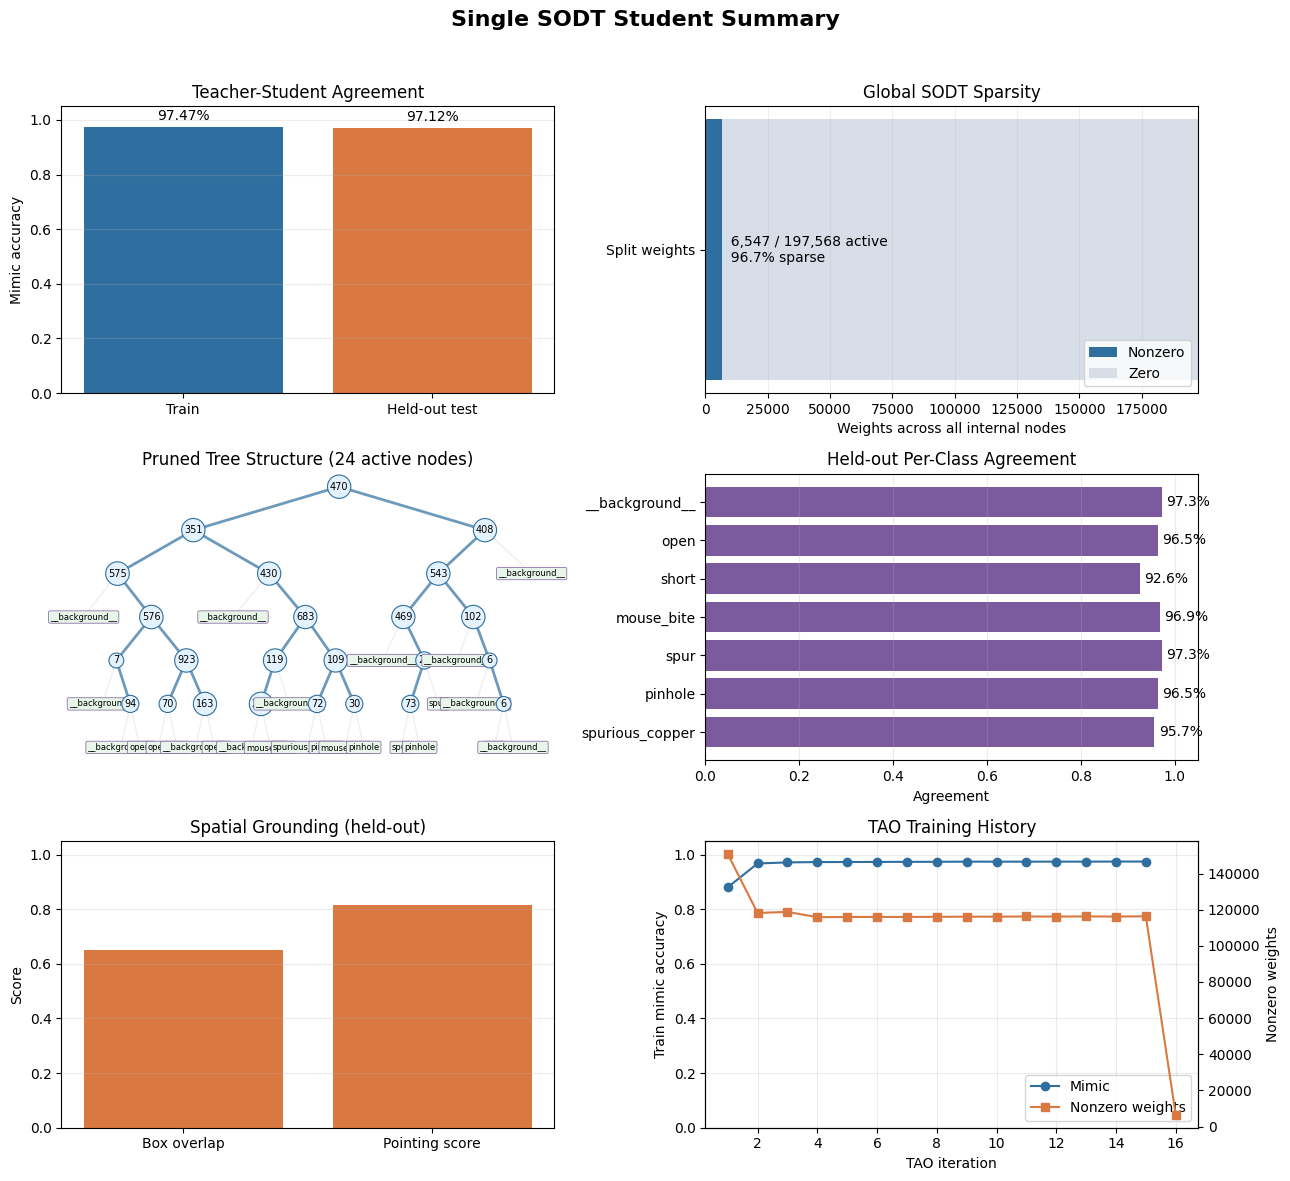

Train mimic accuracy: 0.9747
Held-out mimic accuracy: 0.9712
Nonzero weights: 6,547 / 197,568 (96.7% sparse)
Macro F1: 0.9046
Necessity flip rate: 0.1507
Sufficiency preservation: 1.0000
Deletion AUC: 0.7718
Insertion AUC: 0.8175
Per-node active count: 24 / 63


In [7]:
train_metrics = summary["metrics"]
heldout_metrics = heldout_eval["metrics"]

feature_dim = int(np.prod(summary["feature_shape"]))
total_split_weights = train_metrics["num_internal_nodes"] * feature_dim
nonzero_weights = train_metrics["nonzero_weights"]
zero_weights = max(total_split_weights - nonzero_weights, 0)
weight_sparsity = zero_weights / max(total_split_weights, 1)

train_mimic = next(
    e["mimic_accuracy"] for e in reversed(summary["history"]) if "mimic_accuracy" in e
)
test_mimic = heldout_metrics["mimic_accuracy"]
tree = load_symbolic_tree(symbolic_checkpoint_path)
per_node_counts = tree.nonzero_weight_counts()
tree_class_names = summary["class_names"]
per_node_active = sorted(
    [(i, c) for i, c in enumerate(per_node_counts) if c > 0],
    key=lambda x: x[1],
    reverse=True,
)

class_agreement = heldout_metrics["per_class_agreement_vs_teacher"]
class_names_list = list(class_agreement.keys())
class_values = [class_agreement[name] for name in class_names_list]

history = pd.DataFrame(summary["history"])
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle("Single SODT Student Summary", fontsize=16, fontweight="bold")

ax = axes[0, 0]
accuracy_labels = ["Train", "Held-out test"]
accuracy_values = [train_mimic, test_mimic]
accuracy_bars = ax.bar(accuracy_labels, accuracy_values, color=["#2F6F9F", "#D97941"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mimic accuracy")
ax.set_title("Teacher-Student Agreement")
ax.bar_label(
    accuracy_bars, labels=[f"{value:.2%}" for value in accuracy_values], padding=3
)
ax.grid(axis="y", alpha=0.25)

ax = axes[0, 1]
ax.barh(["Split weights"], [nonzero_weights], color="#2F6F9F", label="Nonzero")
ax.barh(
    ["Split weights"],
    [zero_weights],
    left=[nonzero_weights],
    color="#D7DEE8",
    label="Zero",
)
ax.set_xlim(0, total_split_weights)
ax.set_xlabel("Weights across all internal nodes")
ax.set_title("Global SODT Sparsity")
ax.text(
    nonzero_weights,
    0,
    f"  {nonzero_weights:,} / {total_split_weights:,} active\n  {weight_sparsity:.1%} sparse",
    va="center",
)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[1, 0]
ax.clear()
ax.axis("off")

num_internal = tree.num_internal_nodes
pruned = set()
for idx in range(num_internal):
    if np.all(tree.node_weights[idx] == 0.0) and tree.node_bias[idx] == 0.0:
        pruned.add(idx)

visible_nodes = set()
visible_edges = []
leaf_override = {}


def _build(node, depth):
    visible_nodes.add(node)
    if node >= num_internal:
        return
    if node in pruned:
        curr = node
        while curr < num_internal:
            curr = curr * 2 + 1
        leaf_off = curr - num_internal
        lidx = tree.leaf_labels[leaf_off]
        leaf_override[node] = tree_class_names[int(lidx)]
        return
    left = node * 2 + 1
    right = node * 2 + 2
    visible_edges.append((node, left))
    visible_edges.append((node, right))
    _build(left, depth + 1)
    _build(right, depth + 1)


_build(0, 0)

children_map = {}
for p, c in visible_edges:
    children_map.setdefault(p, []).append(c)

coords = {}
leaf_x = [0]


def _layout(node, depth):
    kids = sorted(children_map.get(node, []))
    if not kids:
        coords[node] = (leaf_x[0], -depth * 2.5)
        leaf_x[0] += 40
    else:
        for c in kids:
            _layout(c, depth + 1)
        xs = [coords[c][0] for c in kids]
        coords[node] = (sum(xs) / len(xs), -depth * 2.5)


_layout(0, 0)

all_x_vals = [v[0] for v in coords.values()]
cx = (max(all_x_vals) + min(all_x_vals)) / 2
for node in coords:
    coords[node] = (coords[node][0] - cx, coords[node][1])

for p, c in visible_edges:
    is_active = c < num_internal and c not in pruned
    color = "#2F6F9F" if is_active else "#cccccc"
    lw = 2 if is_active else 1
    ax.plot(
        [coords[p][0], coords[c][0]],
        [coords[p][1], coords[c][1]],
        color=color,
        lw=lw,
        alpha=0.7 if is_active else 0.3,
    )

for node in sorted(visible_nodes):
    is_leaf = node >= num_internal or node in leaf_override
    x, y = coords[node]
    if is_leaf:
        if node in leaf_override:
            lbl = leaf_override[node]
        else:
            leaf_off = node - num_internal
            lbl = tree_class_names[int(tree.leaf_labels[leaf_off])]
        ax.text(
            x,
            y,
            lbl,
            ha="center",
            va="center",
            fontsize=6,
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="#E8F5E9",
                ec="#7C5A9E",
                lw=0.5,
            ),
        )
    else:
        cnt = per_node_counts[node]
        ax.text(
            x,
            y,
            f"{cnt:,}",
            ha="center",
            va="center",
            fontsize=7,
            bbox=dict(
                boxstyle="circle,pad=0.25",
                fc="#E3F2FD",
                ec="#2F6F9F",
                lw=0.8,
            ),
        )

ax.set_title("Pruned Tree Structure ({} active nodes)".format(len(per_node_active)))

ax = axes[1, 1]
y_positions = np.arange(len(class_names_list))
class_bars = ax.barh(y_positions, class_values, color="#7C5A9E")
ax.set_yticks(y_positions)
ax.set_yticklabels(class_names_list)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Agreement")
ax.set_title("Held-out Per-Class Agreement")
ax.bar_label(class_bars, labels=[f"{value:.1%}" for value in class_values], padding=3)
ax.grid(axis="x", alpha=0.25)

ax = axes[2, 0]
spatial_metric_names = ["box_grounded_roi_overlap", "pointing_score"]
x = np.arange(len(spatial_metric_names))
test_spatial = [heldout_metrics[name] for name in spatial_metric_names]
ax.bar(x, test_spatial, color="#D97941")
ax.set_xticks(x)
ax.set_xticklabels(["Box overlap", "Pointing score"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding (held-out)")
ax.grid(axis="y", alpha=0.25)

ax = axes[2, 1]
if not history.empty:
    ax.plot(
        history["iteration"],
        history["mimic_accuracy"],
        color="#2F6F9F",
        marker="o",
        label="Mimic",
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("TAO iteration")
    ax.set_ylabel("Train mimic accuracy")
    ax.grid(alpha=0.25)
    ax_nonzero = ax.twinx()
    ax_nonzero.plot(
        history["iteration"],
        history["nonzero_weights"],
        color="#D97941",
        marker="s",
        label="Nonzero weights",
    )
    ax_nonzero.set_ylabel("Nonzero weights")
    lines, labels = ax.get_legend_handles_labels()
    extra_lines, extra_labels = ax_nonzero.get_legend_handles_labels()
    ax.legend(lines + extra_lines, labels + extra_labels, loc="lower right")
ax.set_title("TAO Training History")

fig.tight_layout(rect=[0, 0, 1, 0.96])
display(Markdown("### Single SODT Student Metrics"))
plt.show()

print(
    f"Train mimic accuracy: {train_mimic:.4f}\n"
    f"Held-out mimic accuracy: {test_mimic:.4f}\n"
    f"Nonzero weights: {nonzero_weights:,} / {total_split_weights:,} "
    f"({weight_sparsity:.1%} sparse)\n"
    f"Macro F1: {heldout_metrics.get('macro_f1_vs_teacher', 0.0):.4f}\n"
    f"Necessity flip rate: {heldout_metrics.get('necessity_prediction_flip_rate', 0.0):.4f}\n"
    f"Sufficiency preservation: {heldout_metrics.get('sufficiency_prediction_preservation', 0.0):.4f}\n"
    f"Deletion AUC: {heldout_metrics.get('deletion_auc', 0.0):.4f}\n"
    f"Insertion AUC: {heldout_metrics.get('insertion_auc', 0.0):.4f}\n"
    f"Per-node active count: {len(per_node_active)} / {len(per_node_counts)}"
)